<a href="https://colab.research.google.com/github/purvakose96/dataset/blob/main/assignment16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

Saving insurance - insurance.csv to insurance - insurance.csv


In [32]:
filepath = "/content/insurance - insurance.csv"
df = pd.read_csv(filepath)
df.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


In [7]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [8]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [9]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(numerical_cols)

categorical_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['age', 'bmi', 'children', 'expenses'], dtype='object')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


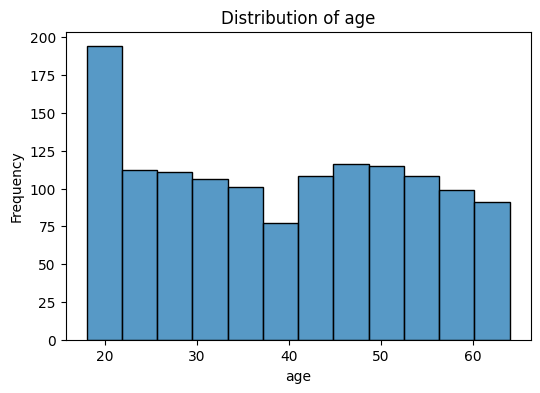

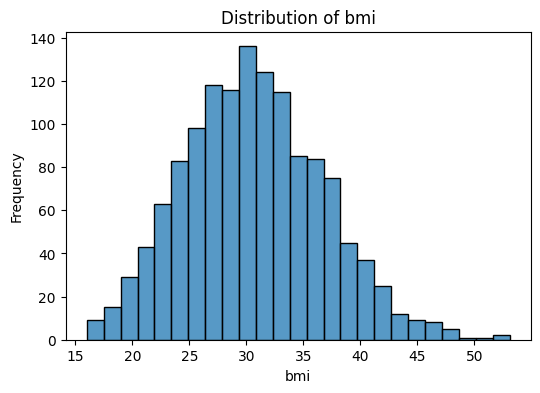

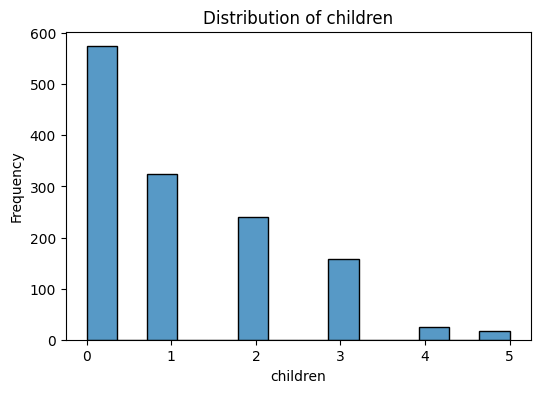

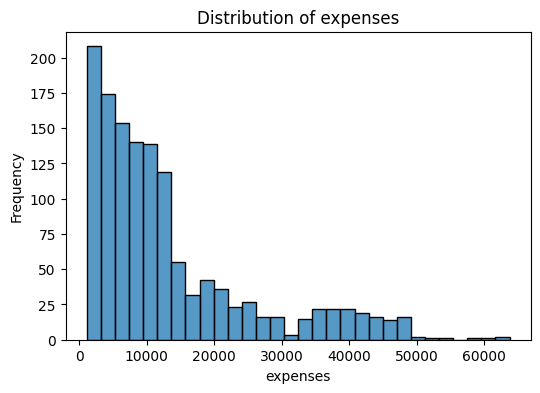

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

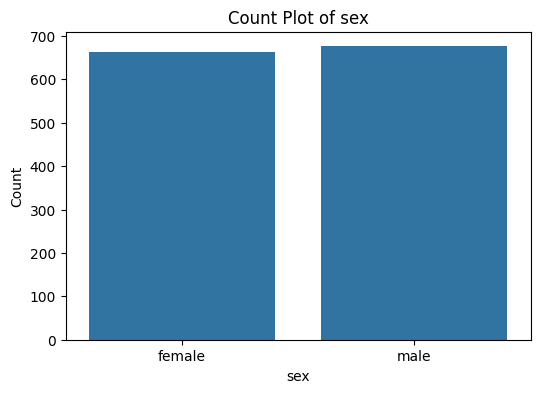

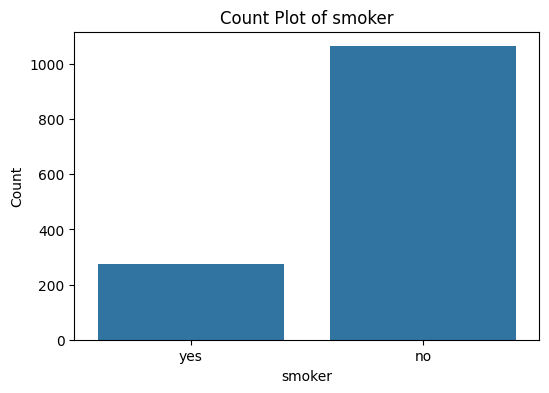

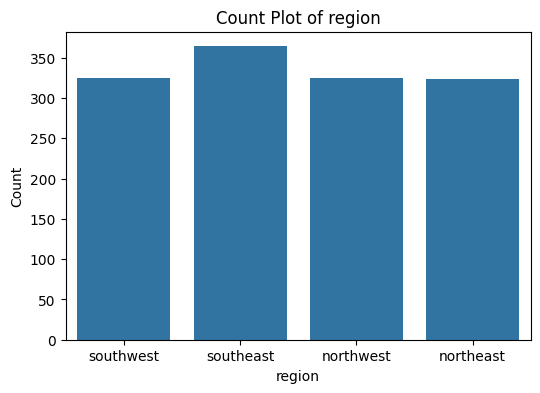

In [12]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

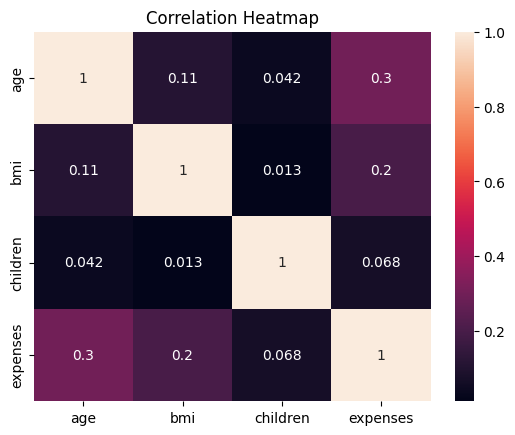

In [26]:

sns.heatmap(df[numerical_cols].corr(),
            annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [33]:
# Average insurance charges
print("Average Charges:", df['charges'].mean())

# Maximum charges
print("Maximum Charges:", df['charges'].max())

# Minimum charges
print("Minimum Charges:", df['charges'].min())

# Average charges for smokers vs non-smokers
print("\nAverage Charges by Smoker Status:")
print(df.groupby('smoker')['charges'].mean())

Average Insurance Expenses: 13270.422414050823
Maximum Expenses: 63770.43
Minimum Expenses: 1121.87

Average Expenses for Smokers vs Non-Smokers:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


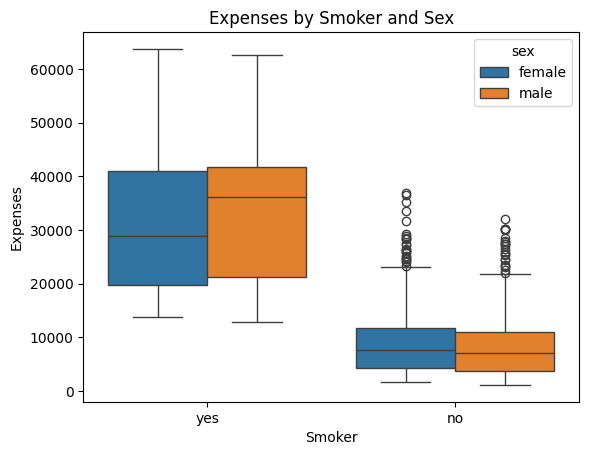

In [37]:
sns.boxplot(x='smoker', y='expenses', hue='sex', data=df)
plt.title("Expenses by Smoker and Sex")
plt.xlabel("Smoker")
plt.ylabel("Expenses")
plt.show()

In [39]:
# Q10 - Analysis Summary

print("1. Average Age :", round(df['age'].mean(), 2))
print("   Average BMI :", round(df['bmi'].mean(), 2))

print("\n2. Average Expenses for Smokers vs Non-Smokers:")
print(df.groupby('smoker')['expenses'].mean())

print("\n3. Region with the Highest Number of Customers:")
print(df['region'].value_counts())

print("\n4. Observations:")
print("- Smokers generally have higher insurance expenses than non-smokers.")
print("- Insurance expenses tend to increase with age.")
print("- BMI shows some positive relationship with expenses.")
print("- The region with the highest count is shown above.")

1. Average Age : 39.21
   Average BMI : 30.67

2. Average Expenses for Smokers vs Non-Smokers:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64

3. Region with the Highest Number of Customers:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

4. Observations:
- Smokers generally have higher insurance expenses than non-smokers.
- Insurance expenses tend to increase with age.
- BMI shows some positive relationship with expenses.
- The region with the highest count is shown above.
